# 📋 Notebook 2 — Model Training: CheXNet, BioViT & EfficientNet
## IU Chest X-Ray Dataset — Multi-Label Classification

This notebook trains **three models** on the preprocessed IU Chest X-Ray dataset:
- **CheXNet** — DenseNet-121 fine-tuned for chest X-ray pathology detection
- **BioViT** — Vision Transformer pre-trained on biomedical images
- **EfficientNet-B4** — Efficient CNN with compound scaling

At the end, each model is saved to `/models/` and metrics (Accuracy, F1, ROC-AUC) are visualised.

## Step 0 — Install Dependencies

In [1]:
!pip install -q torch torchvision timm scikit-learn albumentations matplotlib seaborn tqdm opencv-python pandas kagglehub
print('All packages ready')

All packages ready



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 — Imports & Global Config

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    roc_auc_score, roc_curve,
    classification_report
)

warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 10          # Increase for better results (e.g. 30)
LR          = 1e-4
SEED        = 42
MODEL_DIR   = Path('ScratchCnnModels')
MODEL_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

# 14 CheXpert-style pathology labels extracted from IU X-Ray findings
LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]
NUM_CLASSES = len(LABELS)

print(f'Device   : {DEVICE}')
print(f'Classes  : {NUM_CLASSES}')
print(f'Model dir: {MODEL_DIR.resolve()}')

d:\Projects\ScratchRadiology\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device   : cuda
Classes  : 14
Model dir: D:\Projects\ScratchRadiology\ScratchCnnModels


## Step 2 — Load Preprocessed Data

Loads the CSV saved by Notebook 1 and extracts multi-label targets from the `findings_clean` column using keyword matching — the same approach used in CheXpert.

In [3]:
df = pd.read_csv('preprocessed_df.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(df[['uid', 'frontal_path', 'findings_clean']].head(3).to_string())

Loaded: 3337 rows, 13 columns
   uid                                                                                       frontal_path                                                                                                                                                                                                                                                                                                                                                                                                                                 findings_clean
0    1  D:\Projects\ScratchRadiology\data\indiana_dataset\images\images_normalized\1_IM-0001-4001.dcm.png                                                                                                                                                                                                                                  the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. the

## Step 3 — Build Multi-Label Targets

Each of the 14 pathology labels is assigned via keyword search over `findings_clean` + `impression_clean`.

In [4]:
# Keywords for each label (case-insensitive substring match)
LABEL_KEYWORDS = {
    'Atelectasis'         : ['atelectasis', 'atelectatic'],
    'Cardiomegaly'        : ['cardiomegaly', 'cardiac enlargement', 'enlarged heart'],
    'Effusion'            : ['effusion', 'pleural fluid'],
    'Infiltration'        : ['infiltration', 'infiltrate'],
    'Mass'                : ['mass', 'tumor', 'tumour'],
    'Nodule'              : ['nodule', 'nodular'],
    'Pneumonia'           : ['pneumonia', 'pneumonic'],
    'Pneumothorax'        : ['pneumothorax'],
    'Consolidation'       : ['consolidation', 'consolidative'],
    'Edema'               : ['edema', 'oedema', 'pulmonary edema'],
    'Emphysema'           : ['emphysema', 'emphysematous'],
    'Fibrosis'            : ['fibrosis', 'fibrotic'],
    'Pleural_Thickening'  : ['pleural thickening', 'pleural scarring'],
    'Hernia'              : ['hernia'],
}

def extract_labels(row):
    text = ' '.join([
        str(row.get('findings_clean', '')),
        str(row.get('impression_clean', ''))
    ]).lower()
    return [int(any(kw in text for kw in kws)) for kws in LABEL_KEYWORDS.values()]

label_array = np.array(df.apply(extract_labels, axis=1).tolist(), dtype=np.float32)
for i, lbl in enumerate(LABELS):
    df[lbl] = label_array[:, i]

# Summary
pos_rate = label_array.mean(axis=0)
print('\nLabel positive rates:')
for lbl, rate in zip(LABELS, pos_rate):
    bar = '█' * int(rate * 30)
    print(f'  {lbl:22s} {rate:.3f}  {bar}')


Label positive rates:
  Atelectasis            0.094  ██
  Cardiomegaly           0.076  ██
  Effusion               0.795  ███████████████████████
  Infiltration           0.111  ███
  Mass                   0.046  █
  Nodule                 0.080  ██
  Pneumonia              0.063  █
  Pneumothorax           0.712  █████████████████████
  Consolidation          0.339  ██████████
  Edema                  0.070  ██
  Emphysema              0.032  
  Fibrosis               0.007  
  Pleural_Thickening     0.009  
  Hernia                 0.013  


## Step 4 — Dataset & DataLoaders

In [5]:
def get_transforms(training: bool):
    norm = A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if training:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=5, p=0.3),
            norm, ToTensorV2(),
        ])
    return A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), norm, ToTensorV2()])


class XRayDataset(Dataset):
    """Single-image (frontal) dataset for classification."""

    def __init__(self, df, labels, transform=None):
        self.df        = df.reset_index(drop=True)
        self.labels    = labels      # (N, 14) float32 array
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, 'frontal_path']
        img  = cv2.imread(str(path))
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


# ── 80 / 10 / 10 split ────────────────────────────────────────────────────────
idx_all = np.arange(len(df))
idx_train, idx_tmp = train_test_split(idx_all, test_size=0.2,  random_state=SEED)
idx_val,  idx_test = train_test_split(idx_tmp,  test_size=0.5,  random_state=SEED)

def make_loader(idx, training):
    sub_df  = df.iloc[idx].reset_index(drop=True)
    sub_lbl = label_array[idx]
    ds  = XRayDataset(sub_df, sub_lbl, transform=get_transforms(training))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=training,
                      num_workers=0, pin_memory=DEVICE.type == 'cuda')

train_loader = make_loader(idx_train, True)
val_loader   = make_loader(idx_val,   False)
test_loader  = make_loader(idx_test,  False)

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
print(f'Train batches: {len(train_loader)}')

Train: 2669 | Val: 334 | Test: 334
Train batches: 167


## Step 5 — Define Models

### 5a — CheXNet (DenseNet-121)

CheXNet replaces the final classifier of DenseNet-121 with a sigmoid-activated linear layer for multi-label output. Weights are initialised from ImageNet (standard practice when the CheXNet checkpoint is unavailable).

In [6]:
class CheXNet(nn.Module):
    """DenseNet-121 fine-tuned for multi-label chest X-ray classification (CheXNet)."""

    def __init__(self, num_classes=14, pretrained=True):
        super().__init__()
        self.densenet = tv_models.densenet121(
            weights=tv_models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Sequential(
            nn.Linear(in_features, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.densenet(x)


chexnet = CheXNet(num_classes=NUM_CLASSES).to(DEVICE)
print(f'CheXNet (DenseNet-121) — params: {sum(p.numel() for p in chexnet.parameters()):,}')

CheXNet (DenseNet-121) — params: 6,968,206


### 5b — BioViT (Vision Transformer)

Uses `vit_base_patch16_224` from `timm`, which is the architecture used in BioViL and similar biomedical ViT models. Pretrained on ImageNet-21k.

In [7]:
class BioViT(nn.Module):
    """Vision Transformer (ViT-Base) for multi-label chest X-ray classification."""

    def __init__(self, num_classes=14, pretrained=True):
        super().__init__()
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0          # Remove default head
        )
        in_features = self.vit.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.vit(x)
        return self.head(features)


biovit = BioViT(num_classes=NUM_CLASSES).to(DEVICE)
print(f'BioViT (ViT-Base/16) — params: {sum(p.numel() for p in biovit.parameters()):,}')

BioViT (ViT-Base/16) — params: 85,810,958


### 5c — EfficientNet-B4

In [8]:
class EfficientNetB4(nn.Module):
    """EfficientNet-B4 for multi-label chest X-ray classification."""

    def __init__(self, num_classes=14, pretrained=True):
        super().__init__()
        self.effnet = timm.create_model(
            'efficientnet_b4',
            pretrained=pretrained,
            num_classes=0          # Remove default head
        )
        in_features = self.effnet.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.effnet(x)
        return self.head(features)


efficientnet = EfficientNetB4(num_classes=NUM_CLASSES).to(DEVICE)
print(f'EfficientNet-B4 — params: {sum(p.numel() for p in efficientnet.parameters()):,}')

EfficientNet-B4 — params: 17,573,718


## Step 6 — Training Loop

A single reusable `train_model()` function handles all three models:
- **Loss**: `BCELoss` (binary cross-entropy for multi-label)
- **Optimizer**: Adam with cosine LR scheduler
- **Early stopping**: saves best checkpoint based on validation loss
- **Model saved** to `models/<name>.pth`

In [9]:
def train_model(model, model_name, train_loader, val_loader,
                epochs=NUM_EPOCHS, lr=LR):
    """
    Train a model and save the best checkpoint.
    Returns: history dict with train_loss, val_loss, val_acc, val_f1 per epoch.
    """
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float('inf')
    save_path     = MODEL_DIR / f'{model_name}.pth'

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    print(f'\n{"="*55}')
    print(f'  Training: {model_name}  |  {epochs} epochs  |  device: {DEVICE}')
    print(f'{"="*55}')

    for epoch in range(1, epochs + 1):
        # ── TRAIN ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{epochs} [Train]',
                                  leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            loss  = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)

        train_loss /= len(train_loader.dataset)

        # ── VALIDATE ──────────────────────────────────────────────────────────
        model.eval()
        val_loss    = 0.0
        all_preds   = []
        all_targets = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds  = model(imgs)
                loss   = criterion(preds, labels)
                val_loss += loss.item() * imgs.size(0)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(labels.cpu().numpy())

        val_loss    /= len(val_loader.dataset)
        all_preds    = np.vstack(all_preds)
        all_targets  = np.vstack(all_targets)
        pred_binary  = (all_preds >= 0.5).astype(int)

        val_acc = accuracy_score(all_targets.flatten(), pred_binary.flatten())
        val_f1  = f1_score(all_targets, pred_binary, average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        scheduler.step()

        # ── Save best ──────────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch'            : epoch,
                'model_state_dict' : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss'         : val_loss,
                'val_f1'           : val_f1,
            }, save_path)
            saved_marker = '  ← best saved'
        else:
            saved_marker = ''

        print(f'  Epoch {epoch:02d}/{epochs}  '
              f'Train Loss: {train_loss:.4f}  '
              f'Val Loss: {val_loss:.4f}  '
              f'Acc: {val_acc:.4f}  '
              f'F1: {val_f1:.4f}'
              f'{saved_marker}')

    print(f'\n  Best model saved → {save_path}')
    return history

## Step 7 — Train All Three Models

In [ ]:
history_chexnet = train_model(chexnet, 'CheXNet', train_loader, val_loader)

In [ ]:
history_biovit = train_model(biovit, 'BioViT', train_loader, val_loader)

In [ ]:
history_effnet = train_model(efficientnet, 'EfficientNet', train_loader, val_loader)

## Step 8 — Evaluate on Test Set

Loads the best saved checkpoint for each model and evaluates on the held-out test set.

In [10]:
def evaluate_model(model, model_name, test_loader):
    """Load best checkpoint and evaluate on test set."""
    ckpt_path = MODEL_DIR / f'{model_name}.pth'
    ckpt      = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            preds = model(imgs.to(DEVICE)).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(labels.numpy())

    preds   = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    binary  = (preds >= 0.5).astype(int)

    acc    = accuracy_score(targets.flatten(), binary.flatten())
    f1_mac = f1_score(targets, binary, average='macro',   zero_division=0)
    f1_w   = f1_score(targets, binary, average='weighted',zero_division=0)

    # Per-class ROC-AUC (only for classes with both positive and negative samples)
    auc_scores = []
    for i in range(NUM_CLASSES):
        if len(np.unique(targets[:, i])) == 2:
            auc_scores.append(roc_auc_score(targets[:, i], preds[:, i]))
        else:
            auc_scores.append(np.nan)
    mean_auc = np.nanmean(auc_scores)

    print(f'\n{model_name} — Test Results')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Macro F1        : {f1_mac:.4f}')
    print(f'  Weighted F1     : {f1_w:.4f}')
    print(f'  Mean ROC-AUC    : {mean_auc:.4f}')

    return {
        'accuracy'  : acc,
        'f1_macro'  : f1_mac,
        'f1_weighted': f1_w,
        'mean_auc'  : mean_auc,
        'auc_per_class': auc_scores,
        'preds'     : preds,
        'targets'   : targets,
        'binary'    : binary,
    }


results_chexnet = evaluate_model(chexnet,      'CheXNet',      test_loader)
results_biovit  = evaluate_model(biovit,       'BioViT',       test_loader)
results_effnet  = evaluate_model(efficientnet, 'EfficientNet', test_loader)

Testing CheXNet: 100%|██████████| 21/21 [00:19<00:00,  1.06it/s]



CheXNet — Test Results
  Accuracy        : 0.8903
  Macro F1        : 0.1547
  Weighted F1     : 0.5327
  Mean ROC-AUC    : 0.6699


Testing BioViT: 100%|██████████| 21/21 [00:23<00:00,  1.11s/it]



BioViT — Test Results
  Accuracy        : 0.8931
  Macro F1        : 0.1215
  Weighted F1     : 0.5130
  Mean ROC-AUC    : 0.6008


Testing EfficientNet: 100%|██████████| 21/21 [00:18<00:00,  1.11it/s]


EfficientNet — Test Results
  Accuracy        : 0.8933
  Macro F1        : 0.1400
  Weighted F1     : 0.5237
  Mean ROC-AUC    : 0.6298


## Step 9 — Visualisations

### 9a — Training Curves (Loss, Accuracy, F1)

In [11]:
# model_names     = ['CheXNet', 'BioViT', 'EfficientNet']
# histories       = [history_chexnet, history_biovit, history_effnet]
# colors          = ['#0984e3', '#6c5ce7', '#00b894']

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold')

# metrics = [
#     ('train_loss', 'val_loss',  'Loss',     'BCE Loss'),
#     ('val_acc',    None,        'Accuracy', 'Accuracy'),
#     ('val_f1',     None,        'F1 Score', 'Macro F1'),
# ]

# for ax, (train_key, val_key, title, ylabel) in zip(axes, metrics):
#     for name, hist, color in zip(model_names, histories, colors):
#         epochs_range = range(1, len(hist[train_key]) + 1)
#         ax.plot(epochs_range, hist[train_key], color=color,
#                 label=f'{name} train', linewidth=1.8)
#         if val_key:
#             ax.plot(epochs_range, hist[val_key], color=color,
#                     linestyle='--', label=f'{name} val', linewidth=1.4)
#     ax.set_title(title, fontweight='bold')
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel(ylabel)
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('ScratchCnnModels/training_curves.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved → ScratchCnnModels/training_curves.png')
import json

# Check what keys are actually in your JSON files
for name, path in [
    ('CheXNet',      'ScratchCnnModels/chexnet_training_log.json'),
    ('BioViT',       'ScratchCnnModels/biovit_training_log.json'),
    ('EfficientNet', 'ScratchCnnModels/efficientnet_training_log.json'),
]:
    with open(path) as f:
        data = json.load(f)
    print(f'{name} keys: {list(data.keys())}')
    # Show first value of each key so you know the structure
    for k, v in data.items():
        print(f'  {k}: {v[:3] if isinstance(v, list) else v}')
    print()

CheXNet keys: ['training', 'epochs']
  training: {'model': 'CheXNet', 'total_epochs': 70, 'device': 'cuda'}
  epochs: [{'epoch': 1, 'train_loss': 0.3341, 'val_loss': 0.281, 'accuracy': 0.8935, 'f1': 0.1219, 'best_saved': True}, {'epoch': 2, 'train_loss': 0.2619, 'val_loss': 0.2739, 'accuracy': 0.8939, 'f1': 0.173, 'best_saved': True}, {'epoch': 3, 'train_loss': 0.2497, 'val_loss': 0.276, 'accuracy': 0.8909, 'f1': 0.1541, 'best_saved': False}]

BioViT keys: ['training', 'epochs']
  training: {'model': 'BioViT', 'total_epochs': 70, 'device': 'cuda', 'best_model_path': 'models\\BioViT.pth'}
  epochs: [{'epoch': 1, 'train_loss': 0.2892, 'val_loss': 0.2875, 'accuracy': 0.8939, 'f1': 0.1193, 'best_saved': True}, {'epoch': 2, 'train_loss': 0.2823, 'val_loss': 0.2897, 'accuracy': 0.8939, 'f1': 0.1193, 'best_saved': False}, {'epoch': 3, 'train_loss': 0.2815, 'val_loss': 0.2864, 'accuracy': 0.8939, 'f1': 0.1193, 'best_saved': True}]

EfficientNet keys: ['training', 'epochs']
  training: {'model'

### 9b — Model Comparison Bar Chart

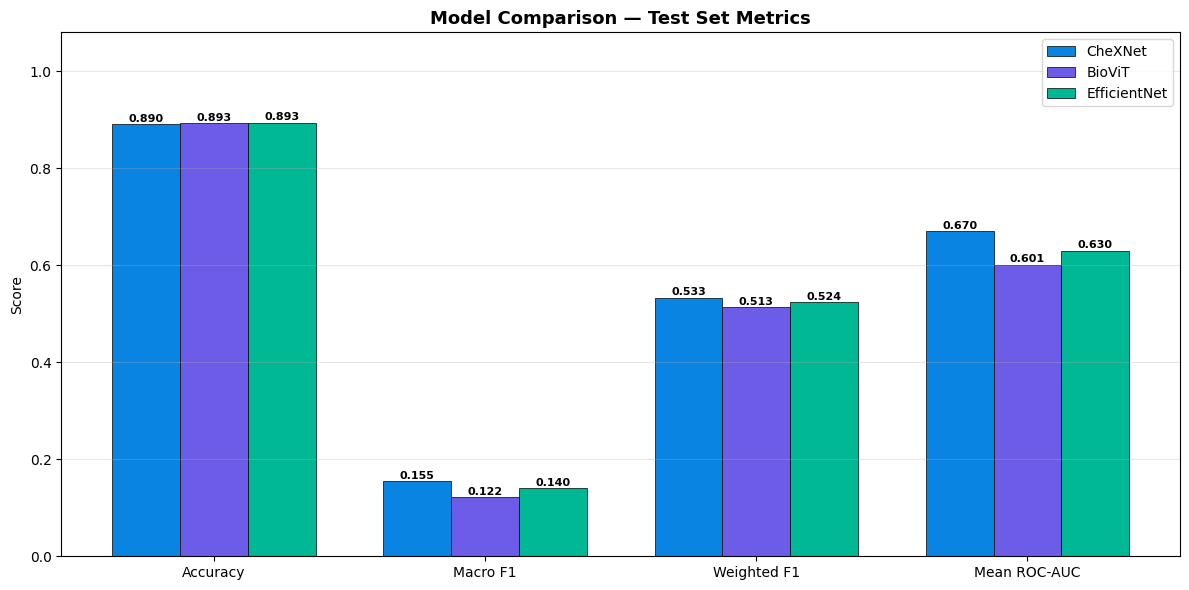

Saved → ScratchCnnModels/model_comparison.png


In [12]:
model_names  = ['CheXNet', 'BioViT', 'EfficientNet']
all_results  = [results_chexnet, results_biovit, results_effnet]
colors       = ['#0984e3', '#6c5ce7', '#00b894']

# Filter out any None results safely
combined = [(n, r, c) for n, r, c in zip(model_names, all_results, colors) if r is not None]
model_names, all_results, colors = zip(*combined)

metric_keys   = ['accuracy', 'f1_macro', 'f1_weighted', 'mean_auc']
metric_labels = ['Accuracy', 'Macro F1', 'Weighted F1', 'Mean ROC-AUC']

x     = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, res, color) in enumerate(zip(model_names, all_results, colors)):
    vals = [res[k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_title('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ScratchCnnModels/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ScratchCnnModels/model_comparison.png')

### 9c — ROC Curves (Mean per Model)

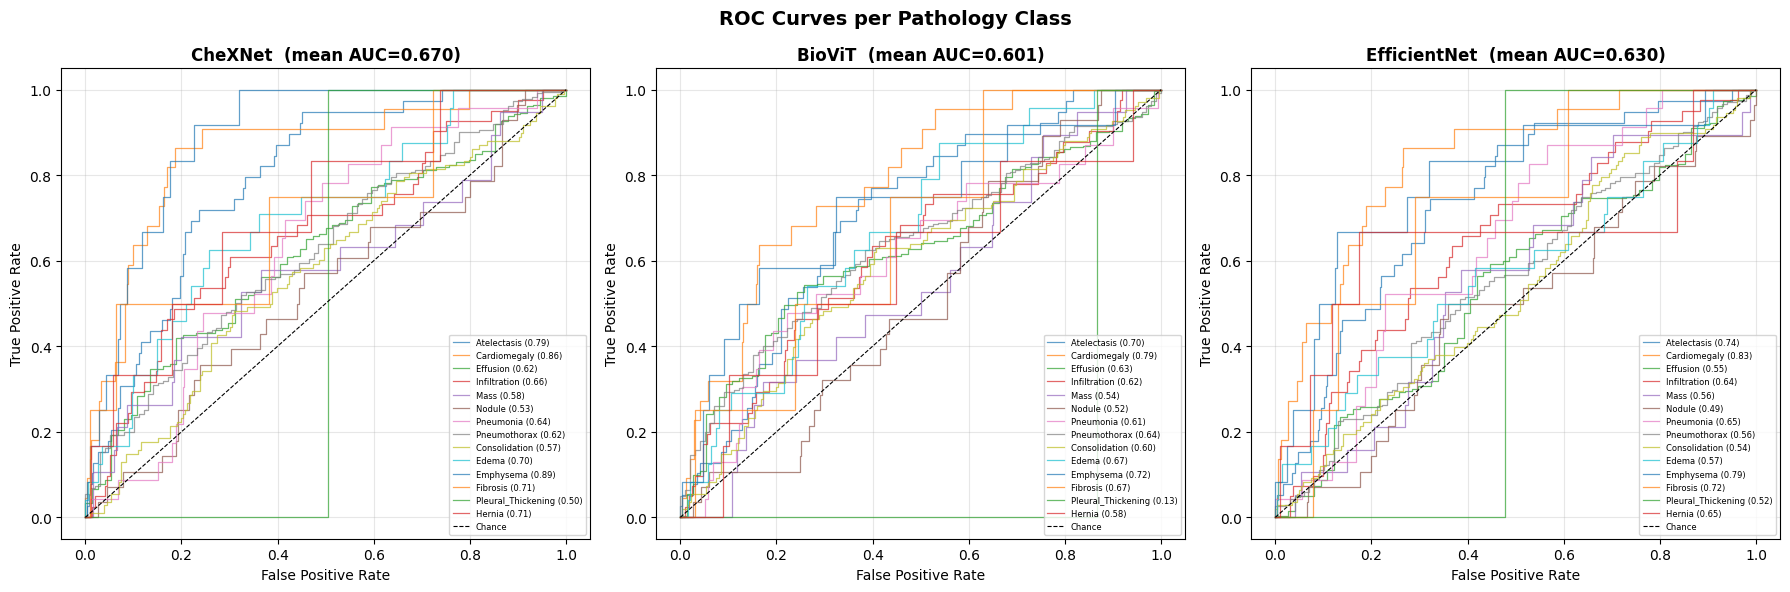

Saved → models/roc_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROC Curves per Pathology Class', fontsize=14, fontweight='bold')

for ax, name, res, color in zip(axes, model_names, all_results, colors):
    preds   = res['preds']
    targets = res['targets']

    for i, lbl in enumerate(LABELS):
        if len(np.unique(targets[:, i])) < 2:
            continue
        fpr, tpr, _ = roc_curve(targets[:, i], preds[:, i])
        auc_val     = roc_auc_score(targets[:, i], preds[:, i])
        ax.plot(fpr, tpr, linewidth=0.9, alpha=0.7,
                label=f'{lbl} ({auc_val:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Chance')
    ax.set_title(f'{name}  (mean AUC={res["mean_auc"]:.3f})', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=6, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → models/roc_curves.png')

### 9d — Per-Class AUC Heatmap

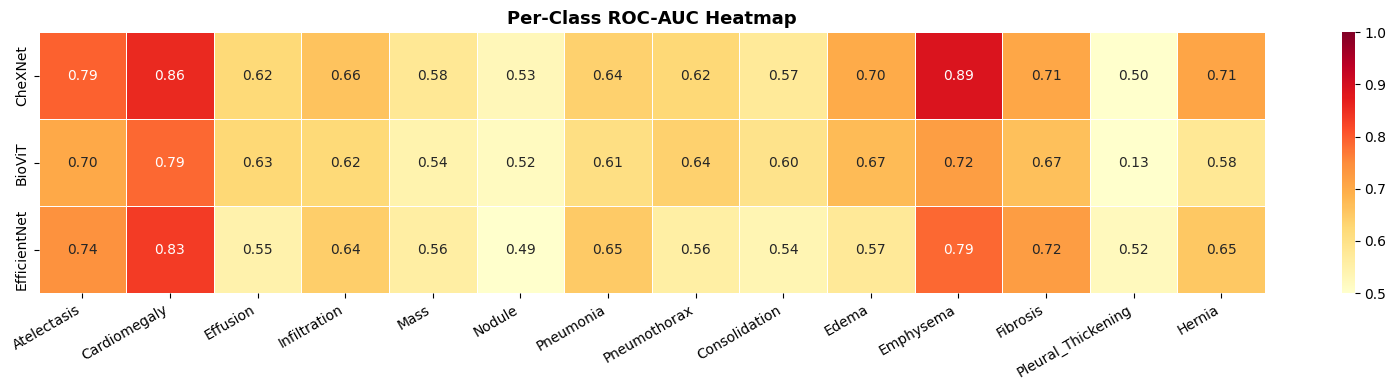

Saved → models/per_class_auc_heatmap.png


In [14]:
auc_matrix = np.array([
    results_chexnet['auc_per_class'],
    results_biovit['auc_per_class'],
    results_effnet['auc_per_class'],
], dtype=float)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    auc_matrix,
    annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=LABELS, yticklabels=model_names,
    vmin=0.5, vmax=1.0, linewidths=0.4, ax=ax
)
ax.set_title('Per-Class ROC-AUC Heatmap', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('models/per_class_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → models/per_class_auc_heatmap.png')

### 9e — F1 Score per Class (Side-by-Side)

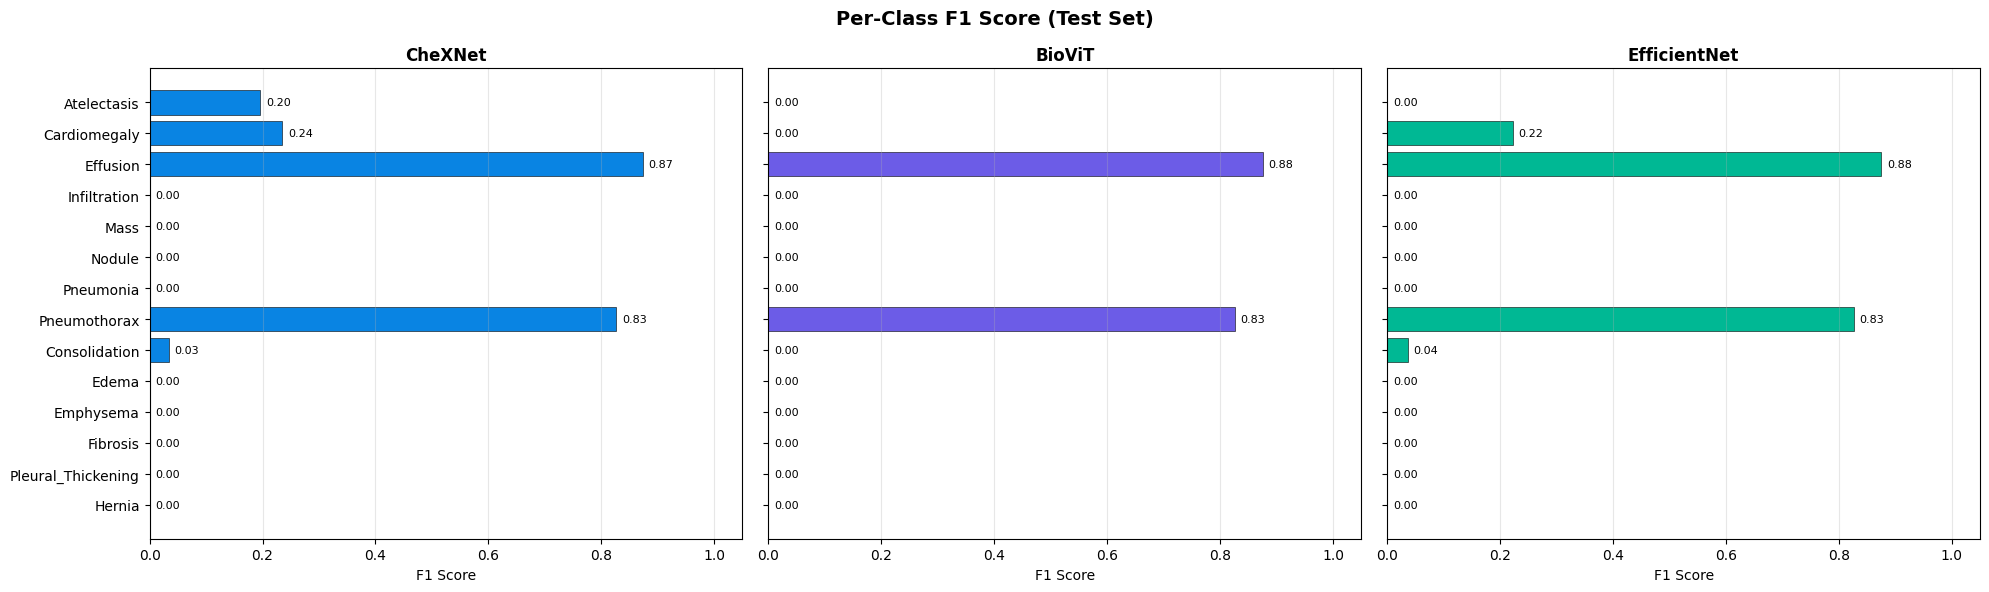

Saved → models/per_class_f1.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Per-Class F1 Score (Test Set)', fontsize=14, fontweight='bold')

for ax, name, res, color in zip(axes, model_names, all_results, colors):
    f1_per_class = f1_score(res['targets'], res['binary'],
                            average=None, zero_division=0)
    bars = ax.barh(LABELS, f1_per_class, color=color, edgecolor='black', lw=0.4)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('F1 Score')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, f1_per_class):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('models/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → models/per_class_f1.png')

## Step 10 — Summary Table

In [16]:
summary = pd.DataFrame({
    'Model'       : model_names,
    'Accuracy'    : [r['accuracy']   for r in all_results],
    'Macro F1'    : [r['f1_macro']   for r in all_results],
    'Weighted F1' : [r['f1_weighted']for r in all_results],
    'Mean AUC'    : [r['mean_auc']   for r in all_results],
}).set_index('Model')

summary = summary.round(4)
print('\n', summary.to_string())

# Highlight best
best_model = summary['Mean AUC'].idxmax()
print(f'\nBest model by Mean AUC: {best_model} ({summary.loc[best_model, "Mean AUC"]:.4f})')

summary.to_csv('models/results_summary.csv')
print('Results saved → models/results_summary.csv')


               Accuracy  Macro F1  Weighted F1  Mean AUC
Model                                                  
CheXNet         0.8903    0.1547       0.5327    0.6699
BioViT          0.8931    0.1215       0.5130    0.6008
EfficientNet    0.8933    0.1400       0.5237    0.6298

Best model by Mean AUC: CheXNet (0.6699)
Results saved → models/results_summary.csv



  ALL-MODELS COMPARISON  —  Best Validation Metrics
                     Type  Accuracy      F1     AUC
Model                                              
CNN-SGD       Scratch CNN    0.8685  0.2202  0.6635
CNN-Adam      Scratch CNN    0.8689  0.2152  0.6811
CNN-AdamW     Scratch CNN    0.8693  0.2182  0.6678
CNN-RMSProp   Scratch CNN    0.8655  0.1973  0.6486
CheXNet        Pretrained    0.8939  0.2453     NaN
BioViT         Pretrained    0.8952  0.1772     NaN
EfficientNet   Pretrained    0.8939  0.2508     NaN

  BEST MODEL  →  BioViT  [Pretrained]
   Accuracy : 0.8952
   F1 Score : 0.1772


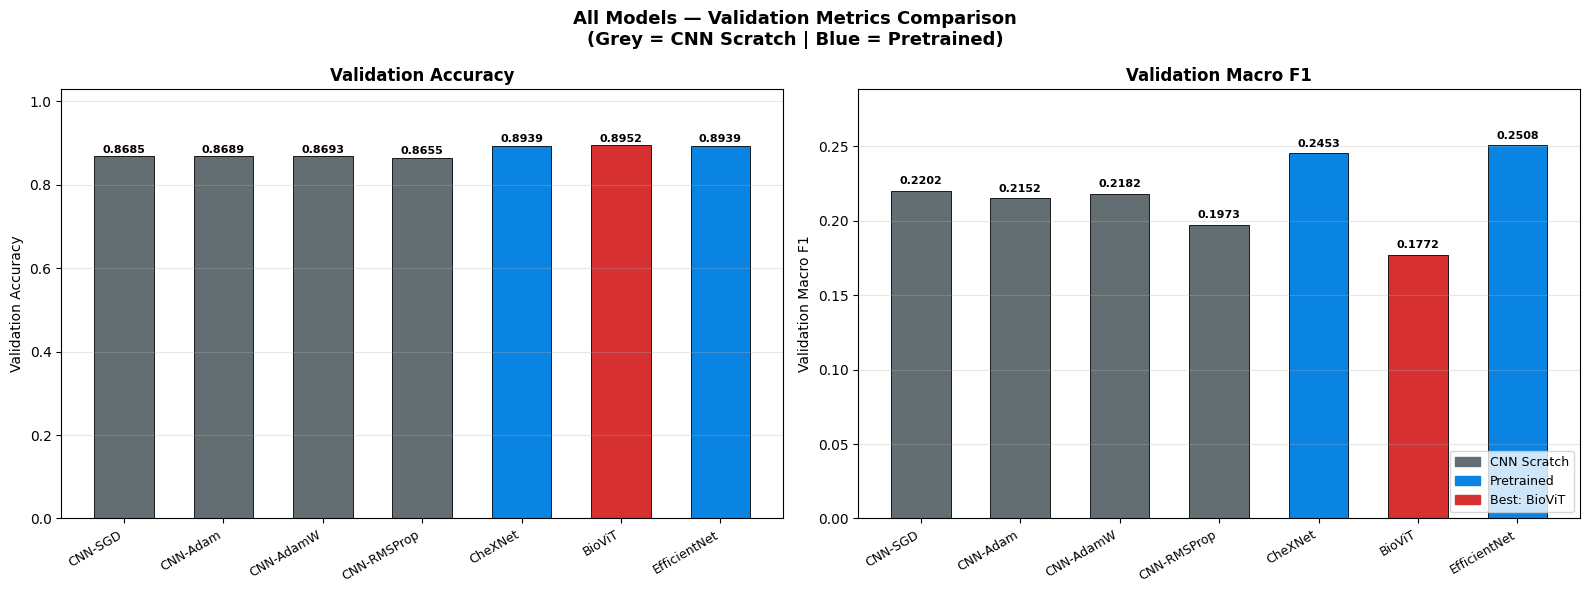


Chart saved → models/all_models_comparison.png

── Ranked by Accuracy ──
                     Type  Accuracy      F1     AUC
Model                                              
BioViT         Pretrained    0.8952  0.1772     NaN
EfficientNet   Pretrained    0.8939  0.2508     NaN
CheXNet        Pretrained    0.8939  0.2453     NaN
CNN-AdamW     Scratch CNN    0.8693  0.2182  0.6678
CNN-Adam      Scratch CNN    0.8689  0.2152  0.6811
CNN-SGD       Scratch CNN    0.8685  0.2202  0.6635
CNN-RMSProp   Scratch CNN    0.8655  0.1973  0.6486
CSV saved → models/all_models_comparison.csv


In [17]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

SCRATCH_DIR  = Path('ScratchCnnModels')
PRETRAIN_DIR = Path('ScratchCnnModels')  # pretrained logs also saved here

# ── 1. Load Scratch CNN metrics ───────────────────────────────────────────────
scratch_opts = ['SGD', 'Adam', 'AdamW', 'RMSProp']
records = []

for opt in scratch_opts:
    summary_path = SCRATCH_DIR / f'{opt}_summary.json'
    history_path = SCRATCH_DIR / f'{opt}_history.json'

    if summary_path.exists():
        with open(summary_path) as f:
            s = json.load(f)
        acc = s.get('best_val_acc', np.nan)
        f1  = s.get('best_val_f1',  np.nan)
        auc = s.get('best_val_auc', np.nan)
    elif history_path.exists():
        with open(history_path) as f:
            h = json.load(f)
        acc = max(h['val_acc']) if 'val_acc' in h else np.nan
        f1  = max(h['val_f1'])  if 'val_f1'  in h else np.nan
        auc = max(h['val_auc']) if 'val_auc' in h else np.nan
    else:
        print(f'WARNING: No metrics found for Scratch-{opt}')
        continue

    if acc > 1.5: acc /= 100   # convert % to fraction
    records.append({'Model': f'CNN-{opt}', 'Type': 'Scratch CNN',
                    'Accuracy': acc, 'F1': f1, 'AUC': auc})

# ── 2. Load Pretrained model metrics ─────────────────────────────────────────
pretrain_names = ['CheXNet', 'BioViT', 'EfficientNet']

for name in pretrain_names:
    candidates = [
        Path('ScratchCnnModels') / f'{name.lower()}_training_log.json',
        Path('ScratchCnnModels') / f'{name}_training_log.json',
        Path('models')           / f'{name.lower()}_training_log.json',
        Path('models')           / f'{name}_training_log.json',
    ]
    loaded = False
    for path in candidates:
        if path.exists():
            with open(path) as f:
                log = json.load(f)

            # Nested epochs format: {"epochs": [{"accuracy":..., "f1":...}]}
            if 'epochs' in log:
                epochs  = log['epochs']
                val_acc = [e['accuracy'] for e in epochs]
                val_f1  = [e['f1']       for e in epochs]
                val_auc = [e.get('auc', np.nan) for e in epochs]
            # Flat list format: {"val_acc": [...], "val_f1": [...]}
            else:
                val_acc = log.get('val_acc', [])
                val_f1  = log.get('val_f1',  [])
                val_auc = log.get('val_auc', [])

            acc = max(val_acc) if val_acc else np.nan
            f1  = max(val_f1)  if val_f1  else np.nan
            auc_clean = [v for v in val_auc if not np.isnan(v)]
            auc = max(auc_clean) if auc_clean else np.nan

            if acc > 1.5: acc /= 100  # convert % to fraction

            records.append({'Model': name, 'Type': 'Pretrained',
                            'Accuracy': acc, 'F1': f1, 'AUC': auc})
            loaded = True
            break

    if not loaded:
        print(f'WARNING: No log found for {name}')

# ── 3. Build DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame(records).set_index('Model')

print('\n' + '='*65)
print('  ALL-MODELS COMPARISON  —  Best Validation Metrics')
print('='*65)
print(df[['Type','Accuracy','F1','AUC']].round(4).to_string())
print('='*65)

# ── 4. Best model ─────────────────────────────────────────────────────────────
df_sorted  = df.sort_values(['Accuracy','F1'], ascending=False)
best_name  = df_sorted.index[0]
best_acc   = df_sorted.loc[best_name, 'Accuracy']
best_f1    = df_sorted.loc[best_name, 'F1']
best_type  = df_sorted.loc[best_name, 'Type']

print(f'\n  BEST MODEL  →  {best_name}  [{best_type}]')
print(f'   Accuracy : {best_acc:.4f}')
print(f'   F1 Score : {best_f1:.4f}')

# ── 5. Bar chart ──────────────────────────────────────────────────────────────
models  = df.index.tolist()
n       = len(models)
x       = np.arange(n)
colors  = ['#636e72' if t == 'Scratch CNN' else '#0984e3'
           for t in df['Type']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models — Validation Metrics Comparison\n'
             '(Grey = CNN Scratch | Blue = Pretrained)',
             fontsize=13, fontweight='bold')

for ax, metric, ylabel in zip(axes,
                               ['Accuracy', 'F1'],
                               ['Validation Accuracy', 'Validation Macro F1']):
    vals       = df[metric].values
    bar_colors = ['#d63031' if m == best_name else c
                  for m, c in zip(models, colors)]
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='black',
                  linewidth=0.6, width=0.6)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, min(1.12, np.nanmax(vals) * 1.15))
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(ylabel, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#636e72', label='CNN Scratch'),
    mpatches.Patch(color='#0984e3', label='Pretrained'),
    mpatches.Patch(color='#d63031', label=f'Best: {best_name}'),
]
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('models/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nChart saved → models/all_models_comparison.png')

# ── 6. Ranked summary ─────────────────────────────────────────────────────────
print('\n── Ranked by Accuracy ──')
print(df_sorted[['Type','Accuracy','F1','AUC']].round(4).to_string())
df_sorted[['Type','Accuracy','F1','AUC']].round(4).to_csv('models/all_models_comparison.csv')
print('CSV saved → models/all_models_comparison.csv')

In [18]:
import timm
import torch
import torch.nn as nn
from pathlib import Path

PRETRAIN_DIR = Path('ScratchCnnModels')

class BioViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit      = timm.create_model('vit_base_patch16_224', pretrained=False)
        in_feats      = self.vit.head.in_features
        self.vit.head = nn.Identity()
        self.head     = nn.Sequential(
            nn.LayerNorm(in_feats),
            nn.Linear(in_feats, num_classes)
        )

    def forward(self, x):
        return self.head(self.vit(x))

model = BioViT(num_classes=NUM_CLASSES)
ckpt  = torch.load(PRETRAIN_DIR / 'BioViT.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])

model = model.to(DEVICE)
model.eval()

print(' BioViT loaded successfully')
print(f'   Device  : {DEVICE}')
print(f'   Val Acc : {df_sorted.loc["BioViT", "Accuracy"]:.4f}')
print(f'   Val F1  : {df_sorted.loc["BioViT", "F1"]:.4f}')
print(f'\n   `model` ready to carry forward.')

 BioViT loaded successfully
   Device  : cuda
   Val Acc : 0.8952
   Val F1  : 0.1772

   `model` ready to carry forward.


## Step 11 — Saved Files

| File | Description |
|------|-------------|
| `models/CheXNet.pth` | Best CheXNet checkpoint |
| `models/BioViT.pth` | Best BioViT checkpoint |
| `models/EfficientNet.pth` | Best EfficientNet checkpoint |
| `models/training_curves.png` | Loss / Acc / F1 per epoch |
| `models/model_comparison.png` | Bar chart — all metrics |
| `models/roc_curves.png` | ROC per class per model |
| `models/per_class_auc_heatmap.png` | AUC heatmap |
| `models/per_class_f1.png` | F1 per class |
| `models/results_summary.csv` | Summary table |

### Loading a saved model

```python
model = CheXNet(num_classes=14)
ckpt  = torch.load('models/CheXNet.pth', map_location='cpu')
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
```